In [27]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io, transform
from sklearn import preprocessing
import numpy as np
import random
from PIL import Image
import joblib
import cv2
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [29]:
# Path to the directory containing the images
image_dir = '/content/Multi Cancer'

# List to store image file paths
image_paths = []

# Loop through the directory and get the paths of the images
for root, dirs, files in os.walk(image_dir):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):  # Adjust file types as needed
            image_paths.append(os.path.join(root, file))

# Create a DataFrame with image paths
dataset = pd.DataFrame(image_paths, columns=['Image_Path'])
print(dataset.head(20))

                                           Image_Path
0   /content/Multi Cancer/breast cancer_malignant/...
1   /content/Multi Cancer/breast cancer_malignant/...
2   /content/Multi Cancer/breast cancer_malignant/...
3   /content/Multi Cancer/breast cancer_malignant/...
4   /content/Multi Cancer/breast cancer_malignant/...
5   /content/Multi Cancer/breast cancer_malignant/...
6   /content/Multi Cancer/breast cancer_malignant/...
7   /content/Multi Cancer/breast cancer_malignant/...
8   /content/Multi Cancer/breast cancer_malignant/...
9   /content/Multi Cancer/breast cancer_malignant/...
10  /content/Multi Cancer/breast cancer_malignant/...
11  /content/Multi Cancer/breast cancer_malignant/...
12  /content/Multi Cancer/breast cancer_malignant/...
13  /content/Multi Cancer/breast cancer_malignant/...
14  /content/Multi Cancer/breast cancer_malignant/...
15  /content/Multi Cancer/breast cancer_malignant/...
16  /content/Multi Cancer/breast cancer_malignant/...
17  /content/Multi Cancer/br

In [30]:
path = r"/content/Multi Cancer"
model_folder = "model"
os.makedirs(model_folder, exist_ok=True)
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
categories

['breast cancer_malignant',
 'oral_cancer',
 'kidney Cancer_tumor',
 'lung &colon cancer_aca',
 'brain cancer_tumor']

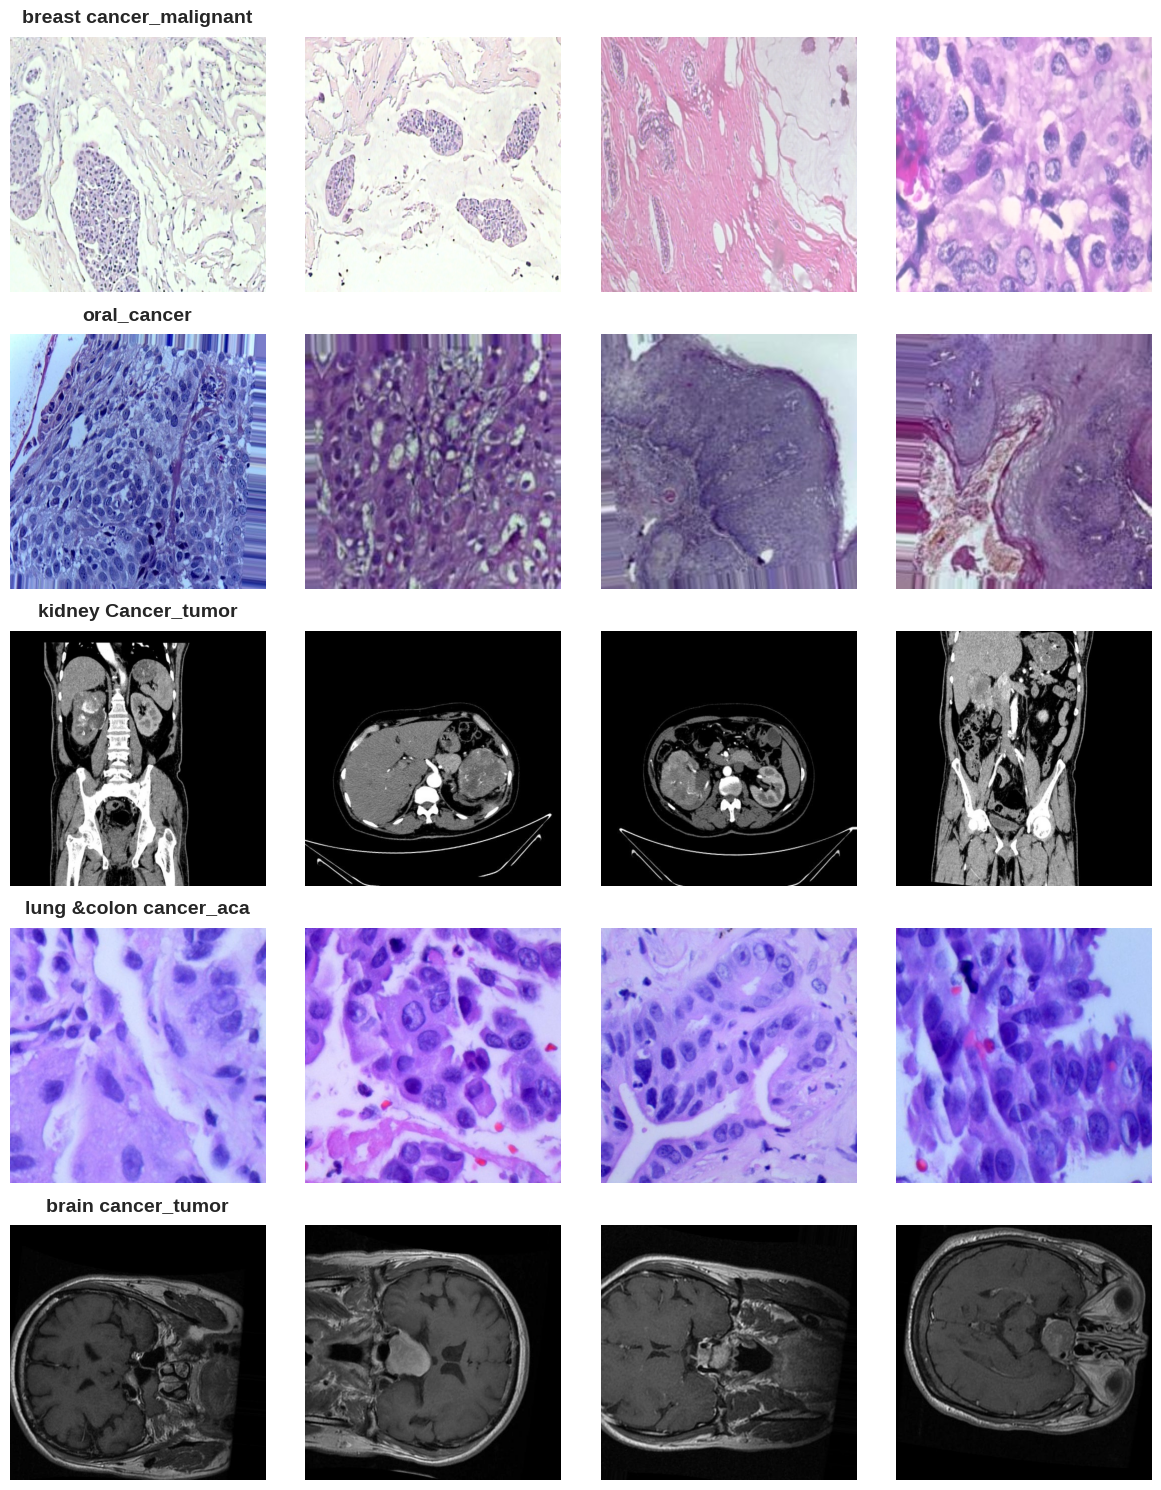

Final image saved at: results/classes_grid.png


In [31]:
num_classes = len(categories)
num_cols = 4  # 4 images per class

# Create results folder if it doesn't exist
results_folder = r"results"
os.makedirs(results_folder, exist_ok=True)

plt.figure(figsize=(num_cols * 3, num_classes * 3))

for i, category in enumerate(categories):
    folder_path = os.path.join(path, category)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(("jpg", "jpeg", "png")) and 'Thumbs.db' not in f]

    selected_files = files[:4]  # pick 4 images per class

    for j, file in enumerate(selected_files):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB

        ax = plt.subplot(num_classes, num_cols, i * num_cols + j + 1)
        ax.imshow(img)
        ax.axis('off')

        # Add class name as a title above the first image of each row
        if j == 0:
            ax.set_title(category, fontsize=14, weight='bold', pad=10, loc='center')

plt.tight_layout()
# Save the final image
output_path = os.path.join(results_folder, "classes_grid.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Final image saved at: {output_path}")

In [32]:
# File paths
X_file = os.path.join(model_folder, "X.npz")
Y_file = os.path.join(model_folder, "Y.npz")

# Load if already exists
if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)['arr_0']
    Y = np.load(Y_file)['arr_0']
    print(f"Loaded X and Y from {model_folder}")

else:
    print("Creating dataset without data augmentation...")

    X = []
    Y = []

    for category in categories:
        folder_path = os.path.join(path, category)
        files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(("jpg", "png", "jpeg")) and 'Thumbs.db' not in f
        ]

        for file in files:
            img_path = os.path.join(folder_path, file)
            print(img_path)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = resize(img, (64, 64, 3), anti_aliasing=True)

            # Flatten image
            X.append(img.flatten())
            Y.append(categories.index(category))

    X = np.array(X)
    Y = np.array(Y)

    # Save dataset
    np.savez_compressed(X_file, X)
    np.savez_compressed(Y_file, Y)
    print(f"Dataset saved to {model_folder}")

print("Dataset shape:", X.shape, Y.shape)


Loaded X and Y from model
Dataset shape: (2500, 12288) (2500,)


In [33]:
df = pd.DataFrame(X)
df['Labels'] = Y
df

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,Labels
0,8.834138e-01,8.836919e-01,8.864337e-01,0.879398,0.897913,0.884476,0.842378,0.873448,0.865721,0.856758,...,0.867192,0.875635,0.886079,0.834120,0.841100,0.877579,0.858589,0.871219,0.877434,0
1,8.754776e-01,7.897552e-01,8.419496e-01,0.873167,0.788627,0.836741,0.887402,0.797857,0.847638,0.900661,...,0.978963,0.997774,0.964524,0.983213,0.997135,0.967874,0.980230,0.997797,0.954385,0
2,8.396347e-01,6.608916e-01,7.725515e-01,0.821328,0.624012,0.752725,0.800107,0.628092,0.736993,0.835397,...,0.905279,0.636937,0.800675,0.858153,0.612837,0.755147,0.892786,0.717085,0.831953,0
3,9.012576e-01,7.213871e-01,9.247645e-01,0.911381,0.737877,0.925451,0.933690,0.760045,0.937152,0.956870,...,0.955768,0.821132,0.934299,0.970231,0.862002,0.919964,0.977263,0.898795,0.912198,0
4,6.872058e-01,7.017638e-01,6.842759e-01,0.688987,0.705444,0.674853,0.696893,0.709374,0.683663,0.699951,...,0.867306,0.875418,0.843837,0.866399,0.872175,0.831590,0.861553,0.870158,0.829807,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,5.056355e-02,5.056355e-02,5.056355e-02,0.055971,0.055971,0.055971,0.062583,0.062583,0.062583,0.079700,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4
2496,3.483582e-04,3.483582e-04,3.483582e-04,0.003305,0.003305,0.003305,0.001333,0.001333,0.001333,0.002397,...,0.003130,0.003130,0.003130,0.010573,0.010573,0.010573,0.007726,0.007726,0.007726,4
2497,8.049829e-07,8.049829e-07,8.049829e-07,0.000238,0.000238,0.000238,0.005035,0.005035,0.005035,0.018492,...,0.000014,0.000014,0.000014,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4
2498,1.177946e-02,1.177946e-02,1.177946e-02,0.012105,0.012105,0.012105,0.011840,0.011840,0.011840,0.011552,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4


In [34]:
Y

array([0, 0, 0, ..., 4, 4, 4])

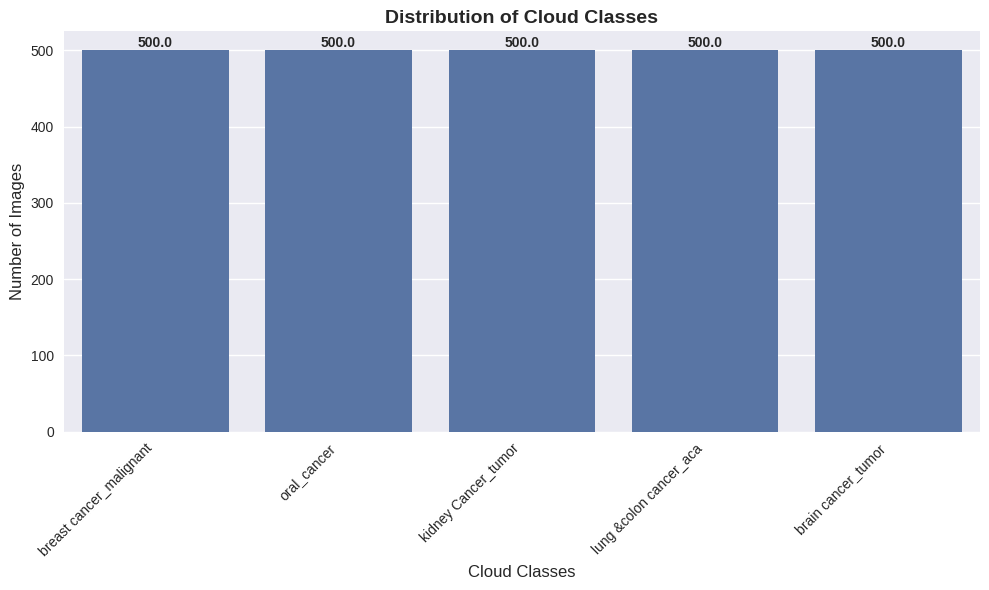

In [35]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=Y)

# Replace x-ticks with class names automatically
ax.set_xticklabels(categories, rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Cloud Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Cloud Classes", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [36]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=77)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

# ──────────────────────────────────────────────────────────────
# Global containers
# ──────────────────────────────────────────────────────────────
metrics_overall = []                    # Overall metrics
class_metrics_storage = {}              # Key = class name → list of dicts (one per model)

def calculateMetrics(algorithm, predict, testY):
    """
    Call this for every model (RFC, DTC, NBC, etc.)
    """
    testY = testY.astype('int')
    predict = predict.astype('int')

    # ── Overall metrics ─────────────────────────────────────
    acc  = accuracy_score(testY, predict) * 100
    prec = precision_score(testY, predict, average='macro', zero_division=0) * 100
    rec  = recall_score(testY, predict, average='macro', zero_division=0) * 100
    f1   = f1_score(testY, predict, average='macro', zero_division=0) * 100

    metrics_overall.append({
        'Model': algorithm,
        'Accuracy':  round(acc, 2),
        'Precision': round(prec, 2),
        'Recall':    round(rec, 2),
        'F1-Score':  round(f1, 2)
    })

    print(f"\n=== {algorithm} Overall ===")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%\n")

    # ── Class-wise metrics ──────────────────────────────────
    report = classification_report(testY, predict, target_names=categories,
                                  output_dict=True, zero_division=0)

    for cls in categories:
        # Initialize list for this class if first time
        if cls not in class_metrics_storage:
            class_metrics_storage[cls] = []

        class_metrics_storage[cls].append({
            'Model':     algorithm,
            'Precision': round(report[cls]['precision'] * 100, 2),
            'Recall':    round(report[cls]['recall'] * 100, 2),
            'F1-Score':  round(report[cls]['f1-score'] * 100, 2)
        })

    # ── Confusion matrix ────────────────────────────────────
    cm = confusion_matrix(testY, predict)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, cbar=False)
    plt.title(f"{algorithm} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


=== Ridge Classifier Overall ===
Accuracy  : 88.80%
Precision : 88.89%
Recall    : 88.85%
F1-Score  : 88.70%



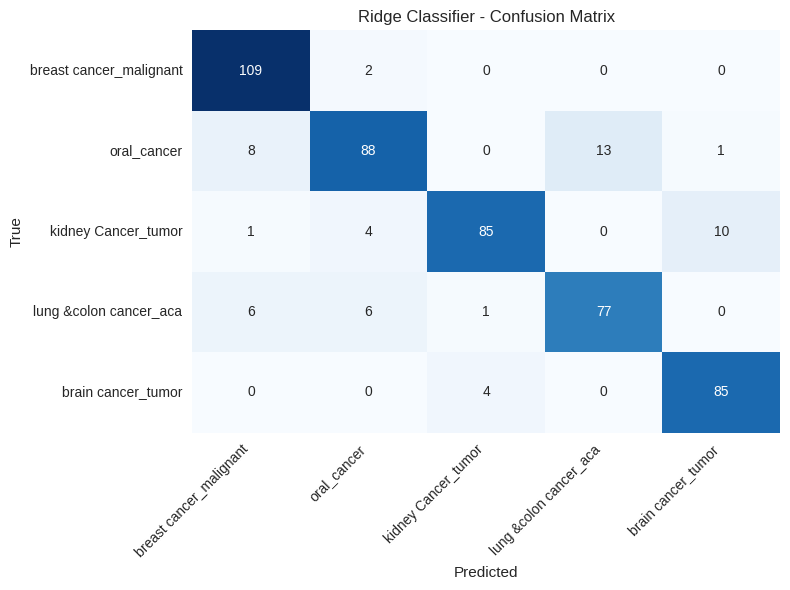

In [38]:
from sklearn.linear_model import RidgeClassifier
import joblib
import os

model_path = r"model/ridge_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train Ridge Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    ridge_classifier = joblib.load(model_path)
    predict = ridge_classifier.predict(x_test)
    calculateMetrics("Ridge Classifier", predict, y_test)

else:
    ridge_classifier = RidgeClassifier(
        alpha=1.0,
        random_state=42
    )

    # Train the classifier
    ridge_classifier.fit(x_train, y_train)

    # Predict on test
    predict = ridge_classifier.predict(x_test)

    # Save model
    joblib.dump(ridge_classifier, model_path)
    print("Ridge Classifier model trained and model saved.")

    calculateMetrics("Ridge Classifier", predict, y_test)



=== Nearest Centroid Classifier Overall ===
Accuracy  : 92.80%
Precision : 93.17%
Recall    : 92.99%
F1-Score  : 92.92%



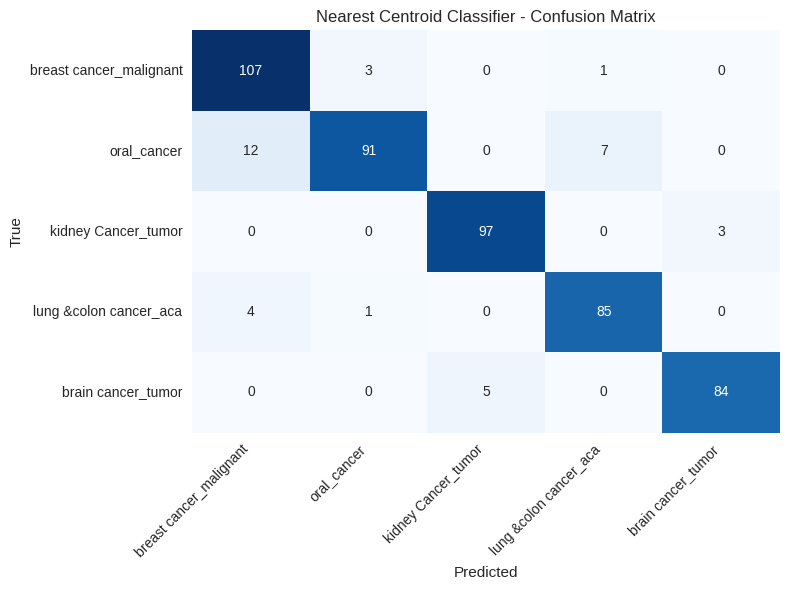

In [39]:
from sklearn.neighbors import NearestCentroid
import joblib
import os

model_path = r"model/nearest_centroid.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train Nearest Centroid model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    nearest_centroid = joblib.load(model_path)
    predict = nearest_centroid.predict(x_test)
    calculateMetrics("Nearest Centroid Classifier", predict, y_test)

else:
    nearest_centroid = NearestCentroid(
        metric='euclidean',
        shrink_threshold=None
    )

    # Train the classifier
    nearest_centroid.fit(x_train, y_train)

    # Predict on test
    predict = nearest_centroid.predict(x_test)

    # Save model
    joblib.dump(nearest_centroid, model_path)
    print("Nearest Centroid model trained and model saved.")

    calculateMetrics("Nearest Centroid Classifier", predict, y_test)



=== Passive Aggressive Classifier Overall ===
Accuracy  : 96.00%
Precision : 95.96%
Recall    : 96.15%
F1-Score  : 95.98%



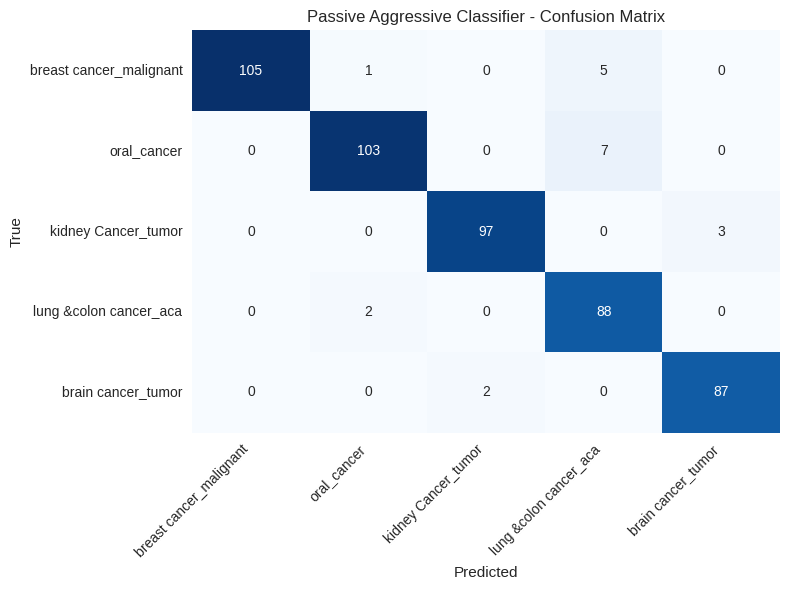

In [40]:
from sklearn.linear_model import PassiveAggressiveClassifier
import joblib
import os

model_path = r"model/passive_aggressive.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train Passive Aggressive model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    passive_aggressive = joblib.load(model_path)
    predict = passive_aggressive.predict(x_test)
    calculateMetrics("Passive Aggressive Classifier", predict, y_test)

else:
    passive_aggressive = PassiveAggressiveClassifier(
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )

    # Train the classifier
    passive_aggressive.fit(x_train, y_train)

    # Predict on test
    predict = passive_aggressive.predict(x_test)

    # Save model
    joblib.dump(passive_aggressive, model_path)
    print("Passive Aggressive model trained and model saved.")

    calculateMetrics("Passive Aggressive Classifier", predict, y_test)


In [41]:
def create_per_class_dataframes():
    if not metrics_overall:
        print("No models evaluated yet!")
        return None

    overall_df = pd.DataFrame(metrics_overall)
    overall_df = overall_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

    print("\n" + "="*60)
    print("OVERALL MODEL COMPARISON")
    print("="*60)
    print(overall_df.round(4))
    print()

    class_dfs = {}
    for cls, records in class_metrics_storage.items():
        df = pd.DataFrame(records)
        df = df.set_index('Model')[['Precision', 'Recall', 'F1-Score']]

        var_name = cls.replace(" ", "_").replace("-", "_") + "_df"
        globals()[var_name] = df
        class_dfs[cls] = df   # key by original class name (more readable)

        print(f"{cls.upper()} CLASS PERFORMANCE".center(60))
        print("-" * 60)
        print(df.round(4))
        print()

    return overall_df, class_dfs
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 7)

def plot_overall_with_values():
    ax = overall_df.plot(kind='bar', width=0.8, edgecolor='black', alpha=0.9)
    plt.title('Overall Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_per_class_metric_universal(metric_name):
    # Reconstruct correct class names from the original storage (universal!)
    class_names = list(class_metrics_storage.keys())  # e.g., ['Cirriform Clouds', 'Clear Sky', ...]

    # Build DataFrame: rows = models, columns = clean class names
    data = pd.DataFrame()
    for cls in class_names:
        records = class_metrics_storage[cls]
        df = pd.DataFrame(records).set_index('Model')
        data[cls] = df[metric_name]

    # Ensure same model order as overall_df
    data = data.loc[overall_df.index]

    # Plot
    plt.figure()
    ax = data.plot(kind='bar', width=0.82, edgecolor='black', alpha=0.9)

    plt.title(f'{metric_name} per Cloud Class', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel(f'{metric_name} (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Cloud Class', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of every bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9.5, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [42]:
 overall_df, class_dfs = create_per_class_dataframes()


OVERALL MODEL COMPARISON
                               Accuracy  Precision  Recall  F1-Score
Model                                                               
Ridge Classifier                   88.8      88.89   88.85     88.70
Nearest Centroid Classifier        92.8      93.17   92.99     92.92
Passive Aggressive Classifier      96.0      95.96   96.15     95.98

         BREAST CANCER_MALIGNANT CLASS PERFORMANCE          
------------------------------------------------------------
                               Precision  Recall  F1-Score
Model                                                     
Ridge Classifier                   87.90   98.20     92.77
Nearest Centroid Classifier        86.99   96.40     91.45
Passive Aggressive Classifier     100.00   94.59     97.22

               ORAL_CANCER CLASS PERFORMANCE                
------------------------------------------------------------
                               Precision  Recall  F1-Score
Model                        

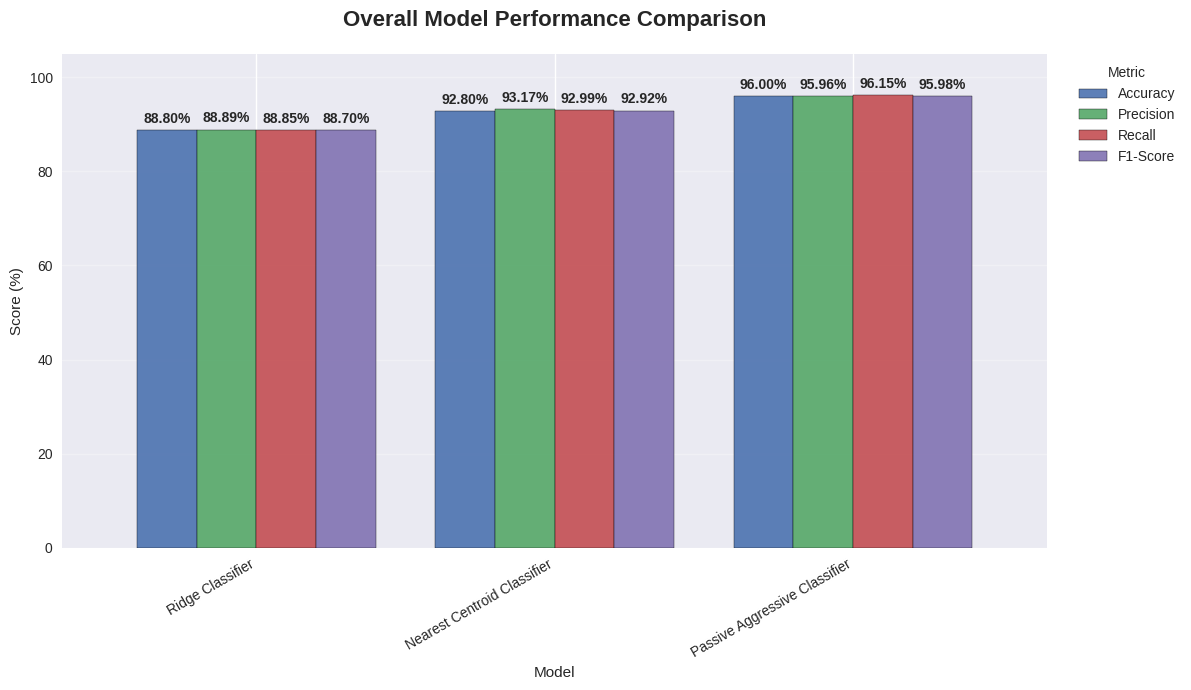

In [43]:
plot_overall_with_values()

In [43]:
plot_per_class_metric_universal('Precision')

<Figure size 1200x700 with 0 Axes>

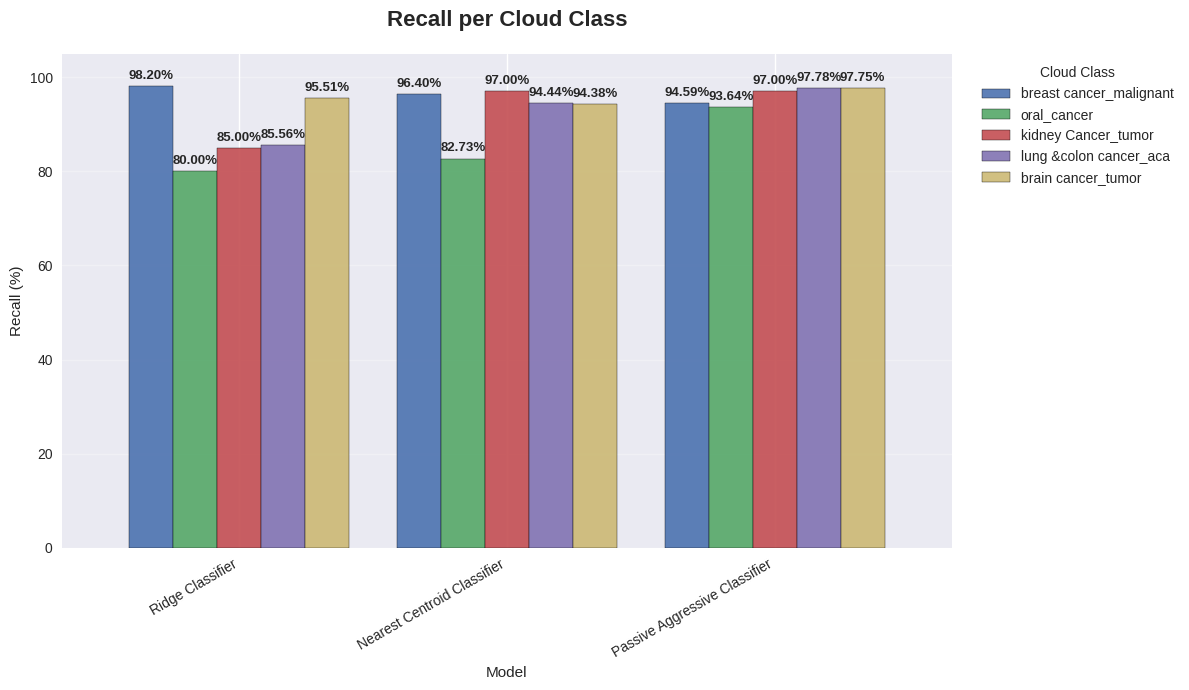

In [44]:
plot_per_class_metric_universal('Recall')

<Figure size 1200x700 with 0 Axes>

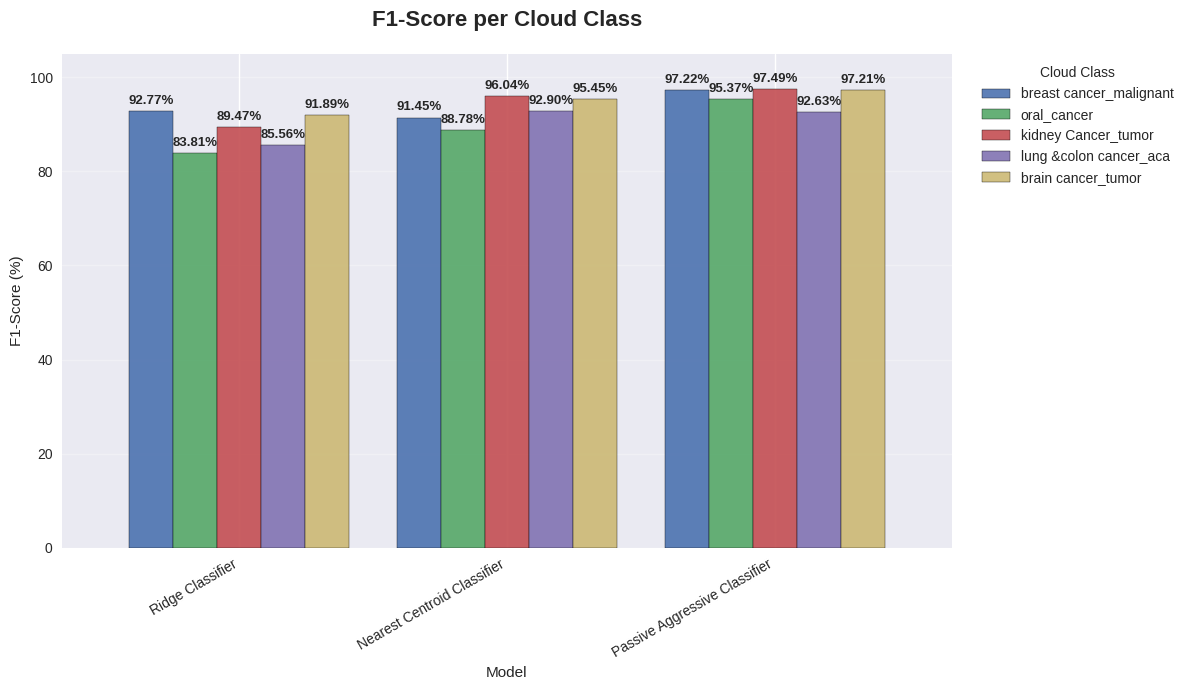

In [45]:
plot_per_class_metric_universal('F1-Score')

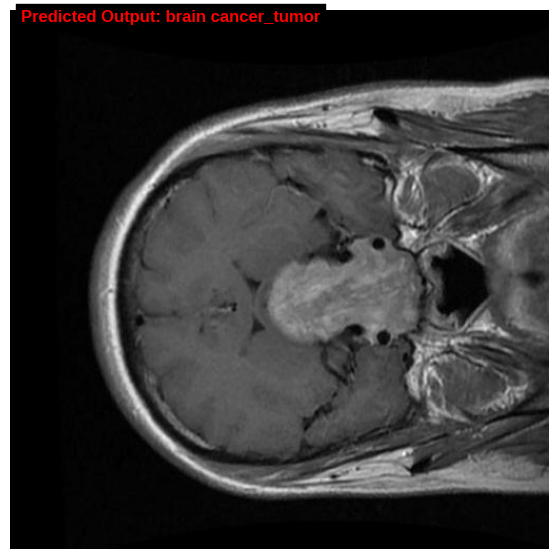

Predicted Class: brain cancer_tumor


In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.preprocessing.image import load_img

def predict_image(image_path):
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to training size
    img = resize(img, (64, 64, 3), anti_aliasing=True)

    # Flatten (IMPORTANT)
    img_array = img.flatten().reshape(1, -1)

    # Direct prediction
    predicted_class = passive_aggressive.predict(img_array)[0]

    return predicted_class



image_path = r"/content/Multi Cancer/brain cancer_tumor/brain_tumor_4081.jpg"


# Predict
output_number = predict_image(image_path)
output_name = categories[output_number]

# Show image
img = load_img(image_path)
plt.imshow(img)
plt.text(
    10, 10,
    f'Predicted Output: {output_name}',
    color='red', fontsize=12, weight='bold', backgroundcolor='black'
)
plt.axis('off')
plt.show()

print("Predicted Class:", output_name)
